# Explaining London’s Crime Geography: Deprivation, Density and Public Transport Accessibility Across Boroughs

## 1. Introduction

Urban crime is not evenly distributed across space. In a city such as London, recorded crime may reflect not only the characteristics of resident populations, but also wider urban processes such as employment concentration, visitor flows, commercial activity and transport accessibility. This is particularly important for central boroughs, where daytime and night-time populations may be much larger than the number of residents.

Previous research suggests two complementary ways of understanding urban crime. Social disorganisation theory links crime to neighbourhood disadvantage, poverty and weakened social control (Shaw and McKay, 1942). By contrast, routine activity theory argues that crime opportunities depend on the convergence of potential offenders, suitable targets and limited guardianship in everyday activity spaces (Cohen and Felson, 1979). Environmental criminology and crime pattern theory further emphasise the role of urban nodes, paths and movement patterns in shaping where crime occurs (Brantingham and Brantingham, 1993).

This study uses London borough-level recorded crime data and augments it with population density, IMD, PTAL and borough boundary data. This design is informed by London-based research showing that crime rates have spatial patterns related to socio-economic characteristics (Zhou et al., 2023), and by recent work showing that public transport accessibility is spatially uneven and linked to urban inequality (Nie et al., 2024). The study therefore asks whether higher recorded crime rates are better explained by deprivation alone, or by deprivation, density and public transport accessibility together.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Research Questions

The main research question of this study is:

**Are higher recorded crime rates in London boroughs better explained by deprivation alone, or by a combination of deprivation, population density and public transport accessibility?**

To answer this, three sub-questions are addressed:

**RQ1: How do recorded crime rates vary across London boroughs after normalising by resident population?**

**RQ2: Is deprivation alone sufficient to explain borough-level crime rates, or do population density and public transport accessibility improve the explanation?**

**RQ3: Can London boroughs be grouped into distinct crime–urban function profiles based on crime rates, deprivation, density and accessibility?**

RQ1 is addressed through descriptive statistics and spatial mapping. RQ2 is examined using correlation analysis and OLS regression. RQ3 is explored through K-means clustering.

## 3. Data

This study uses one main dataset and four supplementary datasets. The main dataset is the Metropolitan Police Service borough-level recorded crime dataset. A 12-month study period from April 2024 to March 2025 was selected to provide a complete annual period and reduce seasonal bias. The crime data are organised by borough, major crime category, minor crime category and month. Monthly counts were aggregated to calculate annual borough-level total crime counts, and selected major categories such as theft, violence and burglary were also extracted.

To make boroughs more comparable, crime counts were normalised by resident population. The main crime rate variable was calculated as:

`crime_rate_1000 = total_crime_count / resident_population * 1000`

The same approach was used to calculate violence, theft and burglary rates per 1,000 residents. This follows the principle that rates are more appropriate than raw counts when comparing areas with different population sizes.

Supplementary datasets include 2024 borough population and population density, the 2019 Index of Multiple Deprivation (IMD) borough summary measures, 2015 borough-level Public Transport Accessibility Level (PTAL), and London borough boundary data. IMD average score is used as a measure of deprivation, where a higher score indicates greater deprivation. Average PTAL score is used as a proxy for public transport accessibility and urban centrality. Borough boundary data are used for choropleth mapping.

The datasets are not perfectly contemporaneous: crime data cover 2024–2025, population is from 2024, IMD is from 2019 and PTAL is from 2015. IMD and PTAL are therefore treated as structural borough-level indicators rather than annual measures. The analysis should be interpreted as spatial association, not causality. City of London is excluded because it is policed separately by the City of London Police rather than the MPS. The final analysis covers 32 London boroughs.

In [2]:
# GitHub raw data URLs

base_url = "https://raw.githubusercontent.com/Annalise-lii/casa006/main/data/"

crime_path = base_url + "crime_borough.csv"
pop_path = base_url + "population_borough.csv"
imd_path = base_url + "imd_2019_london.xlsx"
ptal_path = base_url + "ptal_borough_2015.csv"
boundary_path = base_url + "london_borough_boundaries.geojson"

In [3]:
# Read data directly from GitHub

crime = pd.read_csv(crime_path)

pop = pd.read_csv(pop_path)

imd_raw = pd.read_excel(
    imd_path,
    sheet_name="Borough summary measures",
    engine="openpyxl"
)

ptal = pd.read_csv(ptal_path)

boroughs = gpd.read_file(boundary_path)

## 4. Data Processing

The crime dataset was originally in wide format, with each month stored as a separate column, such as **202404** and **202405**. The columns from **202404** to **202503** were summed to create an annual count for April 2024 to March 2025. These counts were then aggregated by **BoroughName** to produce **total_crime_count**. Major crime categories were also grouped and pivoted into borough-level variables, including **theft_count**, **violence_count** and **burglary_count**.

The population dataset was filtered to 2024 and reduced to borough name, resident population and population density. The IMD dataset was read from the “Borough summary measures” sheet, using the borough name and IMD average score. The PTAL dataset was reduced to borough name and average PTAL score, which was renamed as **ptal_score**.

To merge the datasets reliably, borough names were standardised by trimming spaces, converting text to lowercase and replacing “&” with “and”. The crime, population, IMD and PTAL tables were then joined using the cleaned borough name. Finally, the merged attribute table was joined to the London borough boundary data to create the final geospatial analysis table.

| Variable | Meaning | Source | Use |
|---|---|---|---|
| total_crime_count | Annual recorded crimes, Apr 2024–Mar 2025 | MPS | Descriptive comparison |
| crime_rate_1000 | Total crimes per 1,000 residents | MPS + population | Main dependent variable |
| violence_rate_1000 | Violence crimes per 1,000 residents | MPS + population | Crime type analysis, clustering |
| theft_rate_1000 | Theft crimes per 1,000 residents | MPS + population | Crime type analysis, clustering |
| resident_population | 2024 borough population | GLA | Rate denominator |
| population_density | Residents per sq km | GLA | Urban density indicator |
| imd_score | IMD 2019 average score | MHCLG/GLA | Deprivation indicator |
| ptal_score | Average PTAL score, 2015 | TfL/GLA | Accessibility / centrality indicator |

In [4]:
# Clean crime data

crime.columns = crime.columns.str.strip()

month_cols = [
    "202404", "202405", "202406", "202407", "202408", "202409",
    "202410", "202411", "202412", "202501", "202502", "202503"
]

crime[month_cols] = crime[month_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
crime["annual_count"] = crime[month_cols].sum(axis=1)

crime_borough_total = (
    crime
    .groupby("BoroughName", as_index=False)["annual_count"]
    .sum()
    .rename(columns={
        "BoroughName": "borough",
        "annual_count": "total_crime_count"
    })
)

crime_major = (
    crime
    .groupby(["BoroughName", "MajorText"], as_index=False)["annual_count"]
    .sum()
)

crime_major_pivot = crime_major.pivot_table(
    index="BoroughName",
    columns="MajorText",
    values="annual_count",
    fill_value=0
).reset_index()

crime_major_pivot.columns.name = None

crime_major_pivot = crime_major_pivot.rename(columns={
    "BoroughName": "borough",
    "THEFT": "theft_count",
    "VIOLENCE AGAINST THE PERSON": "violence_count",
    "ROBBERY": "robbery_count",
    "BURGLARY": "burglary_count",
    "DRUG OFFENCES": "drug_count",
    "PUBLIC ORDER OFFENCES": "public_order_count",
    "VEHICLE OFFENCES": "vehicle_count"
})

crime_borough = crime_borough_total.merge(
    crime_major_pivot,
    on="borough",
    how="left"
)

crime_borough.head()

,borough,total_crime_count,ARSON AND CRIMINAL DAMAGE,burglary_count,drug_count,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,public_order_count,robbery_count,SEXUAL OFFENCES,theft_count,vehicle_count,violence_count
0,Barking and Dagenham,19951,1304.0,947.0,1189.0,3.0,294.0,0.0,117.0,1216.0,866.0,680.0,4274.0,2277.0,6784.0
1,Barnet,28323,1873.0,2423.0,1361.0,4.0,330.0,0.0,132.0,1843.0,749.0,757.0,7192.0,4326.0,7333.0
2,Bexley,16534,1656.0,733.0,830.0,2.0,242.0,0.0,85.0,1112.0,321.0,539.0,3637.0,2241.0,5136.0
3,Brent,32350,1998.0,1799.0,1949.0,2.0,331.0,0.0,222.0,2093.0,1142.0,841.0,9145.0,3557.0,9271.0
4,Bromley,24226,2069.0,1392.0,1015.0,6.0,305.0,0.0,133.0,1582.0,593.0,694.0,6178.0,3673.0,6586.0


In [5]:
# Clean population data

pop.columns = pop.columns.str.strip()

pop_2024 = pop[pop["Year"] == 2024].copy()

pop_borough = pop_2024[[
    "Name",
    "Population",
    "Population_per_square_kilometre"
]].rename(columns={
    "Name": "borough",
    "Population": "resident_population",
    "Population_per_square_kilometre": "population_density"
})

pop_borough.head()

,borough,resident_population,population_density
25,City of London,8526,2936.0
77,Barking and Dagenham,229337,6351.5
129,Barnet,420924,4852.2
181,Bexley,262798,4338.0
233,Brent,353130,8168.1


In [6]:
# Clean IMD data

imd_raw.columns = imd_raw.columns.str.strip()

imd_borough = imd_raw.rename(columns={
    "Local Authority District name (2019)": "borough",
    "IMD - Average score": "imd_score",
    "IMD - Average rank": "imd_average_rank"
})

imd_borough = imd_borough[[
    "borough",
    "imd_score",
    "imd_average_rank"
]]

imd_borough.head()

,borough,imd_score,imd_average_rank
0,City of London,14.720,12420.52
1,Barking and Dagenham,32.768,25551.85
2,Barnet,16.148,13803.35
3,Bexley,16.273,13529.71
4,Brent,25.558,21083.02


In [7]:
# Clean PTAL data

ptal.columns = ptal.columns.str.strip()

ptal_borough = ptal[[
    "Borough Name",
    "AvPTAI2015"
]].rename(columns={
    "Borough Name": "borough",
    "AvPTAI2015": "ptal_score"
})

ptal_borough.head()

,borough,ptal_score
0,Kingston upon Thames,5.425275
1,Croydon,6.757744
2,Bromley,3.592084
3,Hounslow,5.842208
4,Ealing,8.503510


In [8]:
# 7. Clean boundary data

boroughs = boroughs.rename(columns={
    "NAME": "borough"
})

boroughs = boroughs[["borough", "geometry"]].copy()

boroughs.head()

,borough,geometry
0,Kingston upon Thames,"POLYGON ((-0.33068 51.32901, -0.33059 51.32909..."
1,Croydon,"POLYGON ((-0.06402 51.31864, -0.06408 51.31861..."
2,Bromley,"POLYGON ((0.01213 51.2996, 0.01196 51.2998, 0...."
3,Hounslow,"POLYGON ((-0.24456 51.4887, -0.24468 51.48868,..."
4,Ealing,"POLYGON ((-0.41183 51.53408, -0.41188 51.53412..."


In [9]:
# Standardise borough names

def clean_borough_name(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("&", "and")
    )

crime_borough["borough_clean"] = crime_borough["borough"].apply(clean_borough_name)
pop_borough["borough_clean"] = pop_borough["borough"].apply(clean_borough_name)
imd_borough["borough_clean"] = imd_borough["borough"].apply(clean_borough_name)
ptal_borough["borough_clean"] = ptal_borough["borough"].apply(clean_borough_name)
boroughs["borough_clean"] = boroughs["borough"].apply(clean_borough_name)

In [10]:
# Merge non-spatial data

analysis = crime_borough.merge(
    pop_borough[[
        "borough_clean",
        "resident_population",
        "population_density"
    ]],
    on="borough_clean",
    how="left"
)

analysis = analysis.merge(
    imd_borough[[
        "borough_clean",
        "imd_score",
        "imd_average_rank"
    ]],
    on="borough_clean",
    how="left"
)

analysis = analysis.merge(
    ptal_borough[[
        "borough_clean",
        "ptal_score"
    ]],
    on="borough_clean",
    how="left"
)

analysis.head()

,borough,total_crime_count,ARSON AND CRIMINAL DAMAGE,burglary_count,drug_count,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,public_order_count,robbery_count,SEXUAL OFFENCES,theft_count,vehicle_count,violence_count,borough_clean,resident_population,population_density,imd_score,imd_average_rank,ptal_score
0,Barking and Dagenham,19951,1304.0,947.0,1189.0,3.0,294.0,0.0,117.0,1216.0,866.0,680.0,4274.0,2277.0,6784.0,barking and dagenham,229337.0,6351.5,32.768,25551.85,5.583730
1,Barnet,28323,1873.0,2423.0,1361.0,4.0,330.0,0.0,132.0,1843.0,749.0,757.0,7192.0,4326.0,7333.0,barnet,420924.0,4852.2,16.148,13803.35,5.542330
2,Bexley,16534,1656.0,733.0,830.0,2.0,242.0,0.0,85.0,1112.0,321.0,539.0,3637.0,2241.0,5136.0,bexley,262798.0,4338.0,16.273,13529.71,4.552927
3,Brent,32350,1998.0,1799.0,1949.0,2.0,331.0,0.0,222.0,2093.0,1142.0,841.0,9145.0,3557.0,9271.0,brent,353130.0,8168.1,25.558,21083.02,9.223249
4,Bromley,24226,2069.0,1392.0,1015.0,6.0,305.0,0.0,133.0,1582.0,593.0,694.0,6178.0,3673.0,6586.0,bromley,347455.0,2314.3,14.163,11297.45,3.592084


In [11]:
# Merge with borough boundary

analysis_geo = boroughs.merge(
    analysis,
    on="borough_clean",
    how="left",
    suffixes=("_map", "")
)

analysis_geo.head()

,borough_map,geometry,borough_clean,borough,total_crime_count,ARSON AND CRIMINAL DAMAGE,burglary_count,drug_count,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,public_order_count,robbery_count,SEXUAL OFFENCES,theft_count,vehicle_count,violence_count,resident_population,population_density,imd_score,imd_average_rank,ptal_score
0,Kingston upon Thames,"POLYGON ((-0.33068 51.32901, -0.33059 51.32909...",kingston upon thames,Kingston upon Thames,11448.0,943.0,566.0,599.0,0.0,128.0,0.0,62.0,828.0,203.0,361.0,3636.0,947.0,3175.0,189276.0,5079.7,11.381,9412.29,5.425275
1,Croydon,"POLYGON ((-0.06402 51.31864, -0.06408 51.31861...",croydon,Croydon,35361.0,2747.0,1911.0,2290.0,12.0,484.0,0.0,273.0,2254.0,1203.0,1267.0,7977.0,3838.0,11105.0,416582.0,4815.8,22.477,18371.23,6.757744
2,Bromley,"POLYGON ((0.01213 51.2996, 0.01196 51.2998, 0....",bromley,Bromley,24226.0,2069.0,1392.0,1015.0,6.0,305.0,0.0,133.0,1582.0,593.0,694.0,6178.0,3673.0,6586.0,347455.0,2314.3,14.163,11297.45,3.592084
3,Hounslow,"POLYGON ((-0.24456 51.4887, -0.24468 51.48868,...",hounslow,Hounslow,26421.0,1939.0,1320.0,1118.0,2.0,352.0,0.0,137.0,1824.0,663.0,743.0,6756.0,3309.0,8258.0,293167.0,5237.2,21.487,18652.53,5.842208
4,Ealing,"POLYGON ((-0.41183 51.53408, -0.41188 51.53412...",ealing,Ealing,31570.0,1973.0,1754.0,1288.0,0.0,344.0,1.0,184.0,2132.0,973.0,931.0,7969.0,4485.0,9536.0,393434.0,7083.2,22.710,18991.69,8.503510


In [12]:
analysis_geo[
    analysis_geo["total_crime_count"].isna()
][[
    "borough_map",
    "borough_clean",
    "total_crime_count",
    "resident_population",
    "population_density",
    "imd_score",
    "ptal_score"
]]

analysis_geo = analysis_geo[
    analysis_geo["total_crime_count"].notna()
].copy()

In [13]:
analysis_geo["crime_rate_1000"] = (
    analysis_geo["total_crime_count"] / analysis_geo["resident_population"] * 1000
)

analysis_geo["violence_rate_1000"] = (
    analysis_geo["violence_count"] / analysis_geo["resident_population"] * 1000
)

analysis_geo["theft_rate_1000"] = (
    analysis_geo["theft_count"] / analysis_geo["resident_population"] * 1000
)

analysis_geo["burglary_rate_1000"] = (
    analysis_geo["burglary_count"] / analysis_geo["resident_population"] * 1000
)

In [14]:
# Save cleaned non-spatial and spatial datasets

analysis_geo.drop(columns="geometry").to_csv(
    "data/final_analysis_table.csv",
    index=False
)

analysis_geo.to_file(
    "data/final_analysis_geo.geojson",
    driver="GeoJSON"
)

## 5. Methodology

Four methods were used to answer the research questions. First, recorded crime counts were converted into rates per 1,000 residents to allow comparison across boroughs with different population sizes:

`crime_rate_1000 = total_crime_count / resident_population * 1000`

The same calculation was applied to violence, theft and burglary. Raw counts were retained only for comparison, to show how normalisation changes the interpretation of crime geography.

Second, choropleth maps were used to compare the spatial distributions of crime rates, IMD deprivation and PTAL accessibility. This helped assess whether high-crime boroughs overlap more closely with deprived areas or highly accessible central areas.

Third, correlation analysis and OLS regression were used to examine the relationship between crime rates and urban indicators. Two models were compared:

`Model 1: crime_rate_1000 ~ imd_score`

`Model 2: crime_rate_1000 ~ imd_score + population_density + ptal_score`

Model 1 tests a deprivation-only explanation, while Model 2 tests whether density and public transport accessibility improve explanatory power. The results are interpreted as spatial associations rather than causal effects. VIF was used to check multicollinearity, and a sensitivity regression excluding Westminster tested whether the results were driven by this extreme central borough.

Finally, K-means clustering was used to group boroughs into crime–urban function profiles using crime rates, IMD, population density and PTAL. Variables were standardised before clustering, and silhouette scores were used to guide the choice of cluster number. The clusters are interpreted as descriptive profiles, not predictive categories.

## 6. Results and Discussion
The results are organised around the three research questions: spatial variation in crime rates, the explanatory role of deprivation and accessibility, and borough crime–urban function profiles.

### 6.1 Descriptive comparison: crime counts and crime rates

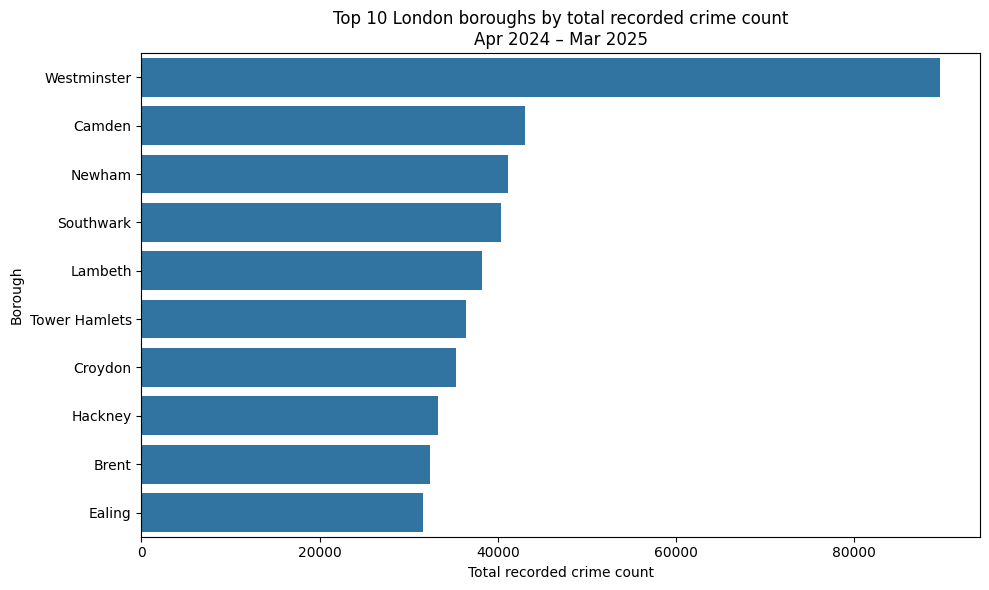

In [15]:
# Top 10 boroughs by total crime count

top_count = analysis_geo.sort_values(
    "total_crime_count",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_count,
    y="borough_map",
    x="total_crime_count"
)
plt.title("Top 10 London boroughs by total recorded crime count\nApr 2024 – Mar 2025")
plt.xlabel("Total recorded crime count")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

Raw crime counts show that Westminster recorded the highest number of crimes between April 2024 and March 2025, followed by Camden, Newham, Southwark and Lambeth. This indicates that recorded crime is concentrated in both central boroughs and some large, densely populated boroughs. However, raw counts are affected by population size and borough function, so they cannot fully represent relative crime exposure.

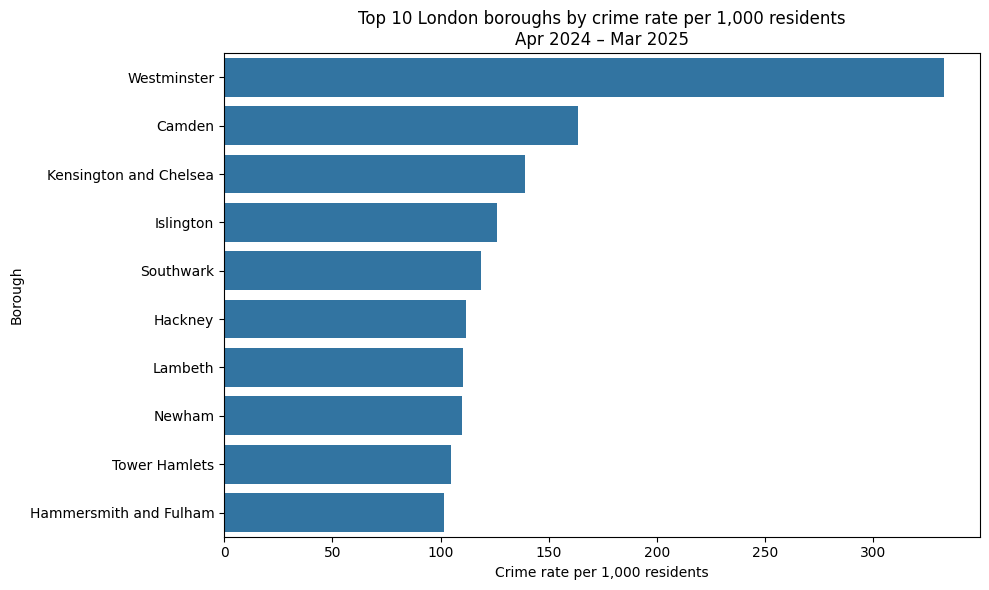

In [16]:
# Top 10 boroughs by crime rate per 1,000 residents

top_rate = analysis_geo.sort_values(
    "crime_rate_1000",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_rate,
    y="borough_map",
    x="crime_rate_1000"
)
plt.title("Top 10 London boroughs by crime rate per 1,000 residents\nApr 2024 – Mar 2025")
plt.xlabel("Crime rate per 1,000 residents")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

After normalising by resident population, the highest crime rates are more clearly concentrated in central and inner London. Westminster remains the most extreme borough, followed by Camden, Kensington and Chelsea, Islington, Southwark and Hackney. This supports the use of rates rather than counts. It also highlights a limitation of resident-population denominators: in highly central boroughs, workers, visitors and tourists may form a large part of the exposed population.

### 6.2 Spatial patterns of crime, deprivation and accessibility

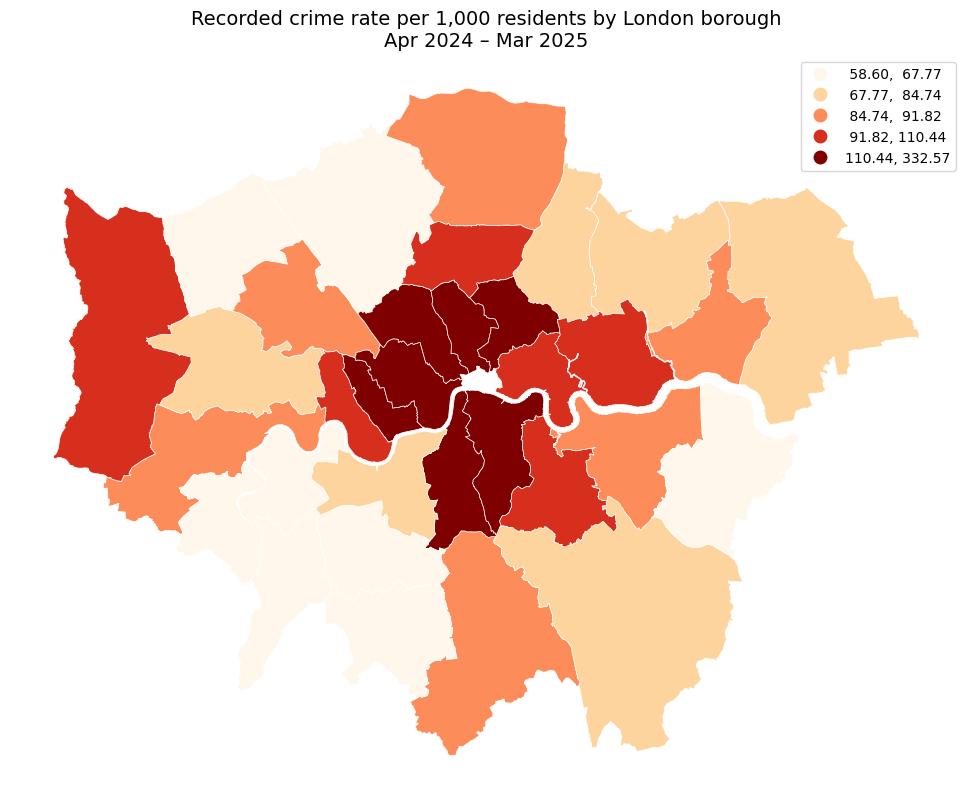

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

analysis_geo.plot(
    column="crime_rate_1000",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    scheme="quantiles",
    k=5,
    ax=ax
)

ax.set_title(
    "Recorded crime rate per 1,000 residents by London borough\nApr 2024 – Mar 2025",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.show()

The crime rate map shows a clear concentration of higher crime rates in central and inner London. Westminster is the most prominent case, while Camden, Islington, Southwark, Lambeth, Kensington and Chelsea, and Hackney also show elevated rates. This spatial pattern suggests that recorded crime rates are not randomly distributed across London boroughs, but are linked to the structure of central and inner-city activity.

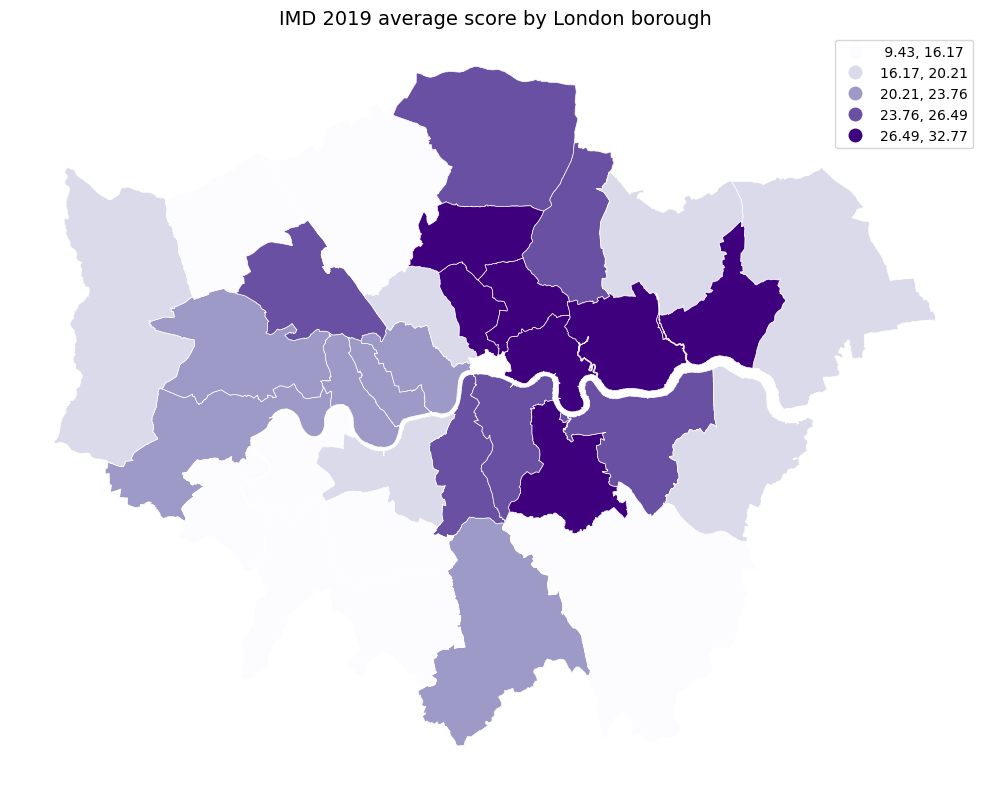

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

analysis_geo.plot(
    column="imd_score",
    cmap="Purples",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    scheme="quantiles",
    k=5,
    ax=ax
)

ax.set_title(
    "IMD 2019 average score by London borough",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.show()

The IMD map shows a different spatial pattern. Higher deprivation is more visible in parts of east, north-east and south London, including Newham, Barking and Dagenham, Hackney, Tower Hamlets and Lewisham. This pattern overlaps only partly with the highest total crime rate areas. For example, Westminster has the highest recorded crime rate but is not among the most deprived boroughs, suggesting that deprivation alone cannot explain overall crime geography.

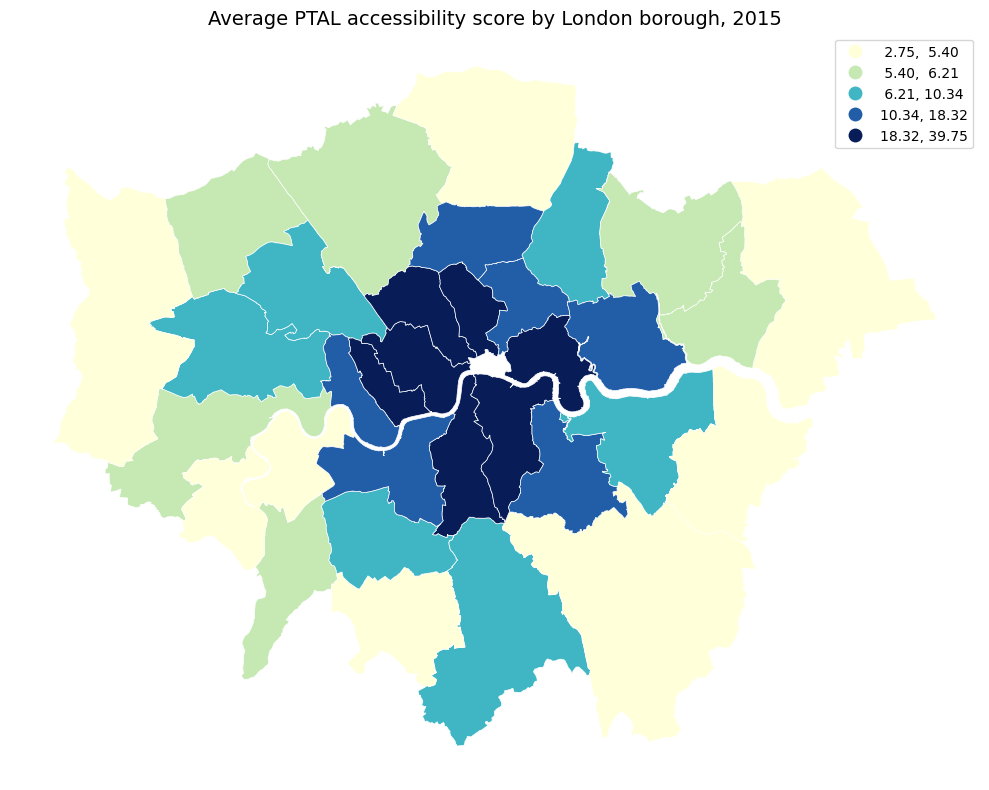

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

analysis_geo.plot(
    column="ptal_score",
    cmap="YlGnBu",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    scheme="quantiles",
    k=5,
    ax=ax
)

ax.set_title(
    "Average PTAL accessibility score by London borough, 2015",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.show()

The PTAL map is spatially closer to the crime rate map than the IMD map. Highly accessible boroughs are concentrated in central and inner London, where high crime rates are also observed. This supports the idea that public transport accessibility may capture urban centrality, movement flows and activity intensity, all of which are relevant to recorded crime opportunities.

### 6.3 Correlation analysis

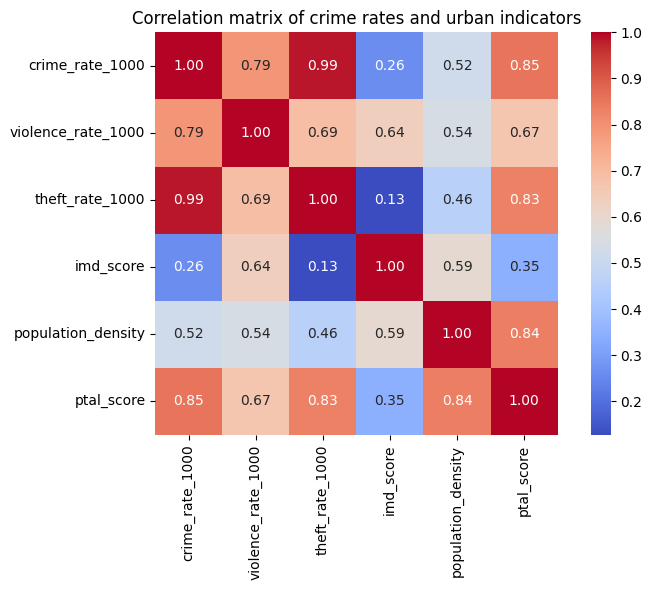

In [20]:
#Correlation analysis
corr_vars = [
    "crime_rate_1000",
    "violence_rate_1000",
    "theft_rate_1000",
    "imd_score",
    "population_density",
    "ptal_score"
]

corr = analysis_geo[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation matrix of crime rates and urban indicators")
plt.tight_layout()
plt.show()

The correlation matrix shows that total crime rate has only a weak positive relationship with IMD score (r = 0.26), but a much stronger relationship with PTAL (r = 0.85). Crime rate is also moderately associated with population density (r = 0.52). Theft rate is especially strongly correlated with PTAL (r = 0.83), while violence rate is more strongly correlated with IMD (r = 0.64). This suggests that different crime types may reflect different urban processes: theft is more closely linked to centrality and accessibility, while violence is more closely linked to deprivation.

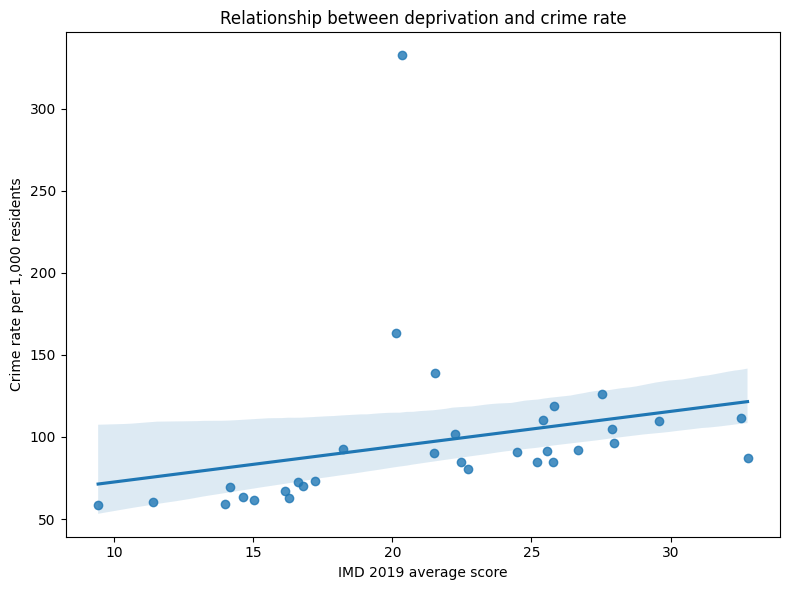

In [21]:
#Scatter plots
plt.figure(figsize=(8, 6))

sns.regplot(
    data=analysis_geo,
    x="imd_score",
    y="crime_rate_1000"
)

plt.title("Relationship between deprivation and crime rate")
plt.xlabel("IMD 2019 average score")
plt.ylabel("Crime rate per 1,000 residents")
plt.tight_layout()
plt.show()

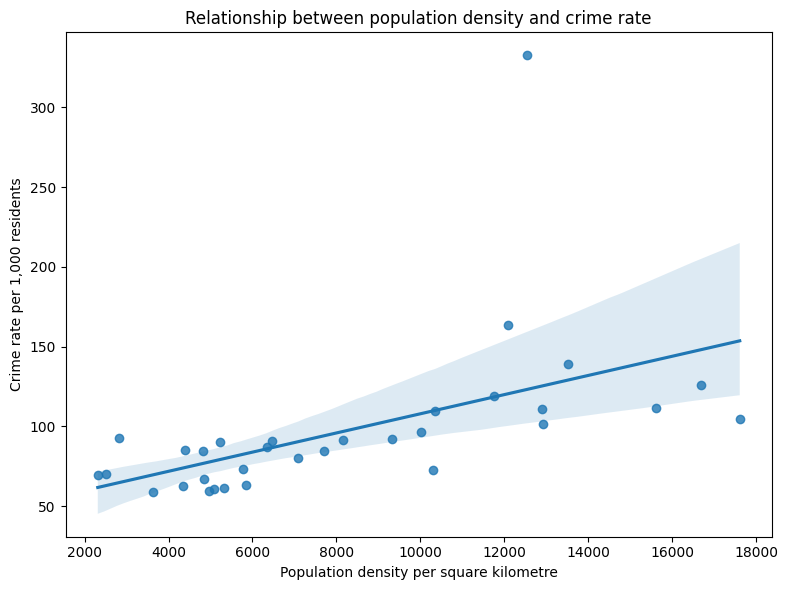

In [22]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=analysis_geo,
    x="population_density",
    y="crime_rate_1000"
)

plt.title("Relationship between population density and crime rate")
plt.xlabel("Population density per square kilometre")
plt.ylabel("Crime rate per 1,000 residents")
plt.tight_layout()
plt.show()

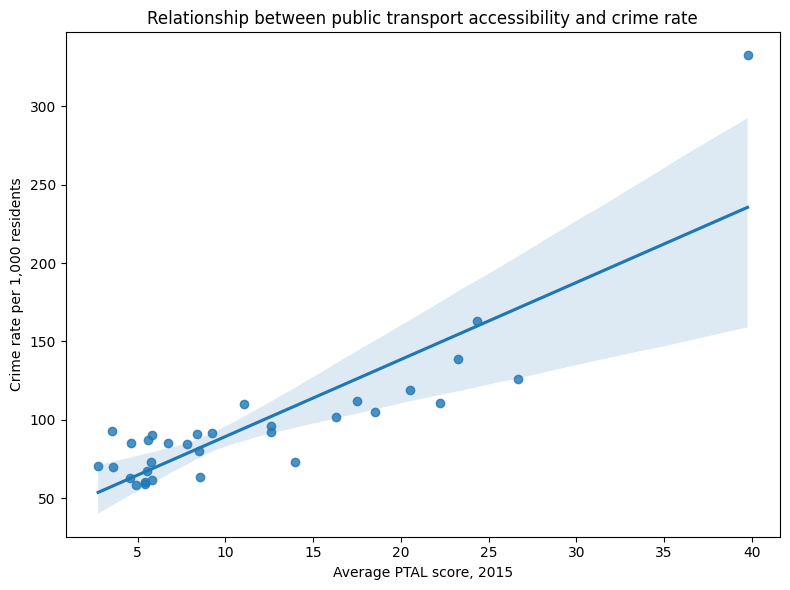

In [23]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=analysis_geo,
    x="ptal_score",
    y="crime_rate_1000"
)

plt.title("Relationship between public transport accessibility and crime rate")
plt.xlabel("Average PTAL score, 2015")
plt.ylabel("Crime rate per 1,000 residents")
plt.tight_layout()
plt.show()

### 6.4 Regression results and diagnostics

In [24]:
import statsmodels.api as sm

reg_df = analysis_geo[[
    "crime_rate_1000",
    "imd_score",
    "population_density",
    "ptal_score"
]].dropna().copy()

In [25]:
#Model 1: IMD only
y = reg_df["crime_rate_1000"]

X1 = reg_df[["imd_score"]]
X1 = sm.add_constant(X1)

model1 = sm.OLS(y, X1).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        crime_rate_1000   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     2.232
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.146
Time:                        18:31:24   Log-Likelihood:                -168.60
No. Observations:                  32   AIC:                             341.2
Df Residuals:                      30   BIC:                             344.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.0337     32.126      1.589      0.1

Model 1 shows that IMD alone explains little variation in borough crime rates. The R² is 0.069 and the IMD coefficient is not statistically significant (p = 0.146). This suggests that deprivation alone is insufficient to explain total recorded crime rates across London boroughs.

In [26]:
#Model 2: IMD + density + PTAL
X2 = reg_df[[
    "imd_score",
    "population_density",
    "ptal_score"
]]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        crime_rate_1000   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     81.96
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.62e-14
Time:                        18:31:24   Log-Likelihood:                -133.26
No. Observations:                  32   AIC:                             274.5
Df Residuals:                      28   BIC:                             280.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 33.5029     11

Model 2 substantially improves explanatory power, with R² increasing from 0.069 to 0.898. PTAL is strongly and positively associated with crime rate, while IMD is also positive and statistically significant. This supports the argument that borough crime rates are better understood through a combination of deprivation and urban centrality indicators than through deprivation alone.

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = reg_df[["imd_score", "population_density", "ptal_score"]].copy()

vif_data = pd.DataFrame()
vif_data["variable"] = vif_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

vif_data

,variable,VIF
0,imd_score,8.404103
1,population_density,23.538552
2,ptal_score,10.519269


The VIF results indicate multicollinearity, especially between population density and PTAL. Therefore, individual regression coefficients, particularly the negative coefficient for population density, should be interpreted cautiously. The main value of the regression is the comparison between the deprivation-only model and the fuller urban model, rather than causal interpretation of each coefficient.

In [28]:
reg_df_no_westminster = analysis_geo[
    analysis_geo["borough_map"] != "Westminster"
][[
    "crime_rate_1000",
    "imd_score",
    "population_density",
    "ptal_score"
]].dropna().copy()

y_sens = reg_df_no_westminster["crime_rate_1000"]
X_sens = reg_df_no_westminster[[
    "imd_score",
    "population_density",
    "ptal_score"
]]
X_sens = sm.add_constant(X_sens)

model_sens = sm.OLS(y_sens, X_sens).fit()
print(model_sens.summary())

print("Original Model 2 R-squared:", round(model2.rsquared, 3))
print("Without Westminster R-squared:", round(model_sens.rsquared, 3))

                            OLS Regression Results                            
Dep. Variable:        crime_rate_1000   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     44.29
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.46e-10
Time:                        18:31:24   Log-Likelihood:                -115.70
No. Observations:                  31   AIC:                             239.4
Df Residuals:                      27   BIC:                             245.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 35.8091      7

Removing Westminster reduces the R² from 0.898 to 0.831, but the model still explains a large share of borough-level variation. This shows that Westminster is influential, but the overall relationship between crime rate and urban centrality is not driven only by this borough. Westminster is therefore treated as a substantively meaningful central activity case rather than simply as an error or outlier.

### 6.5 Borough crime–urban function clusters

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_vars = [
    "crime_rate_1000",
    "violence_rate_1000",
    "theft_rate_1000",
    "imd_score",
    "population_density",
    "ptal_score"
]

cluster_df = analysis_geo[[
    "borough_map",
    "borough_clean"
] + cluster_vars].dropna().copy()

cluster_df.head()

,borough_map,borough_clean,crime_rate_1000,violence_rate_1000,theft_rate_1000,imd_score,population_density,ptal_score
0,Kingston upon Thames,kingston upon thames,60.483104,16.774446,19.210042,11.381,5079.7,5.425275
1,Croydon,croydon,84.883648,26.657417,19.148691,22.477,4815.8,6.757744
2,Bromley,bromley,69.724137,18.954973,17.780720,14.163,2314.3,3.592084
3,Hounslow,hounslow,90.122695,28.168245,23.044886,21.487,5237.2,5.842208
4,Ealing,ealing,80.242175,24.237865,20.254986,22.710,7083.2,8.503510


In [30]:
#Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_vars])

#Silhouette score
silhouette_results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df

,k,silhouette_score
0,2,0.421622
1,3,0.423416
2,4,0.433377
3,5,0.332719
4,6,0.328911


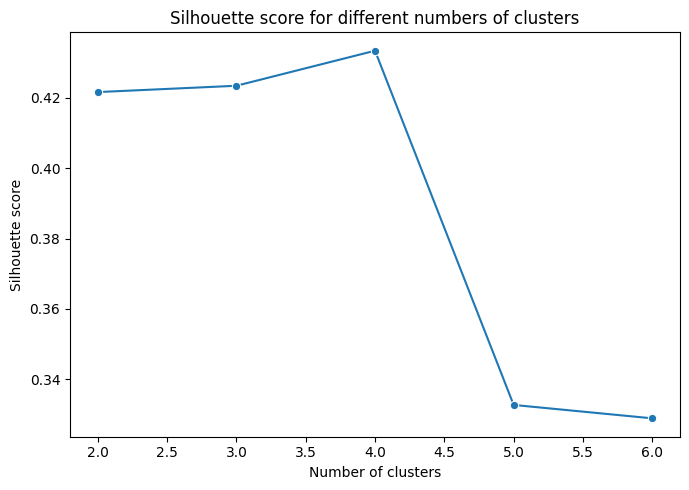

In [31]:
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=silhouette_df,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("Silhouette score for different numbers of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

The silhouette scores suggest that four clusters provide the strongest separation among the tested options. Although one resulting cluster contains only Westminster, this solution is retained because Westminster is substantively meaningful as an extreme central activity borough.

In [32]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_df.head()

,borough_map,borough_clean,crime_rate_1000,violence_rate_1000,theft_rate_1000,imd_score,population_density,ptal_score,cluster
0,Kingston upon Thames,kingston upon thames,60.483104,16.774446,19.210042,11.381,5079.7,5.425275,1
1,Croydon,croydon,84.883648,26.657417,19.148691,22.477,4815.8,6.757744,2
2,Bromley,bromley,69.724137,18.954973,17.780720,14.163,2314.3,3.592084,1
3,Hounslow,hounslow,90.122695,28.168245,23.044886,21.487,5237.2,5.842208,2
4,Ealing,ealing,80.242175,24.237865,20.254986,22.710,7083.2,8.503510,2


In [33]:
analysis_geo = analysis_geo.merge(
    cluster_df[["borough_clean", "cluster"]],
    on="borough_clean",
    how="left"
)

cluster_summary = (
    analysis_geo
    .groupby("cluster")[cluster_vars]
    .mean()
    .round(2)
)

cluster_summary

,crime_rate_1000,violence_rate_1000,theft_rate_1000,imd_score,population_density,ptal_score
cluster,,,,,,
0,122.02,26.63,48.10,25.39,14141.32,21.17
1,67.65,19.25,17.73,14.99,4816.29,5.82
2,90.23,25.94,24.05,25.88,7265.48,8.46
3,332.57,40.24,212.94,20.34,12546.80,39.75


In [34]:
for c in sorted(analysis_geo["cluster"].dropna().unique()):
    print(f"\nCluster {int(c)}:")
    print(
        analysis_geo.loc[
            analysis_geo["cluster"] == c,
            "borough_map"
        ].sort_values().to_list()
    )


Cluster 0:
['Camden', 'Hackney', 'Hammersmith and Fulham', 'Islington', 'Kensington and Chelsea', 'Lambeth', 'Southwark', 'Tower Hamlets']

Cluster 1:
['Barnet', 'Bexley', 'Bromley', 'Harrow', 'Havering', 'Hillingdon', 'Kingston upon Thames', 'Merton', 'Redbridge', 'Richmond upon Thames', 'Sutton', 'Wandsworth']

Cluster 2:
['Barking and Dagenham', 'Brent', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Haringey', 'Hounslow', 'Lewisham', 'Newham', 'Waltham Forest']

Cluster 3:
['Westminster']


The cluster summary identifies four borough profiles. Cluster 0 has high crime rates, high population density and high PTAL, representing an inner-city high-accessibility crime profile. Cluster 1 has low crime rates, low density, low PTAL and low deprivation, representing an outer suburban low-crime profile. Cluster 2 has higher deprivation and medium crime rates, representing a deprived residential medium-crime profile. Cluster 3 consists only of Westminster, representing a central activity outlier with extremely high theft and PTAL scores.

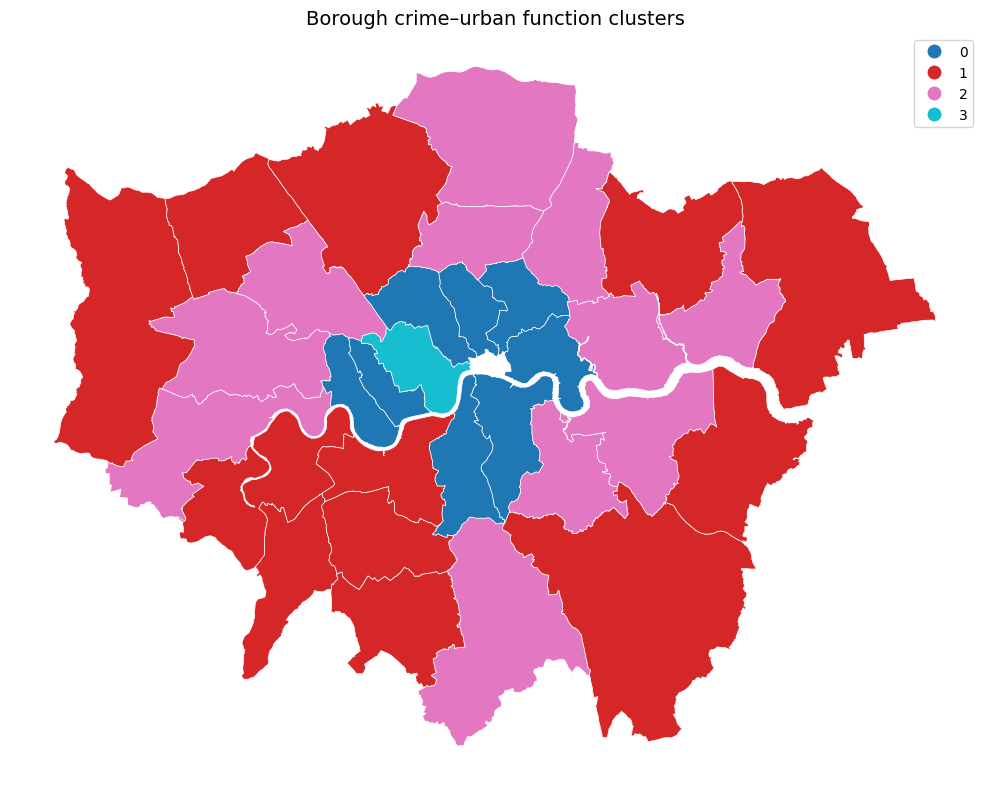

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))

analysis_geo.plot(
    column="cluster",
    categorical=True,
    legend=True,
    linewidth=0.5,
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Borough crime–urban function clusters",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.show()

The cluster map reinforces the distinction between inner-city, suburban and deprived residential boroughs. It shows that London crime geography is not simply a deprivation pattern, but reflects different combinations of social conditions and urban function. In particular, the separation between Cluster 0 and Cluster 2 suggests that high deprivation and high centrality produce different borough crime profiles.

In [36]:
analysis_geo.drop(columns="geometry").to_csv(
    "data/final_analysis_table_with_clusters.csv",
    index=False
)

analysis_geo.to_file(
    "data/final_analysis_geo_with_clusters.geojson",
    driver="GeoJSON"
)


## 7. Conclusion

This study analysed borough-level recorded crime rates in London from April 2024 to March 2025, using deprivation, population density and public transport accessibility to explain spatial variation. The results show that higher crime rates are concentrated in central and inner London, particularly Westminster, Camden, Kensington and Chelsea, and Islington.

The analysis suggests that deprivation alone is insufficient to explain total crime rates. IMD has only a weak relationship with overall crime rate, and the deprivation-only regression model has limited explanatory power. In contrast, PTAL is strongly associated with both total crime rate and theft rate, while adding PTAL and population density greatly improves the regression model. This indicates that total crime and theft are more closely linked to urban centrality, accessibility and activity flows, while violence shows a stronger relationship with deprivation.

K-means clustering identified four crime–urban function profiles: inner-city high-accessibility areas, outer suburban low-crime areas, deprived residential medium-crime areas, and Westminster as a central activity outlier. Overall, London’s crime geography should not be understood simply as a deprivation map, but as the combined outcome of social inequality, density, accessibility and central urban activity.

Key limitations include non-contemporaneous datasets, multicollinearity between PTAL and population density, and the use of resident population as the denominator for central borough crime rates. Future research could improve exposure measurement by including daytime population, visitor flows, employment density or land-use data.

## 8. References

Shaw, C. R. and McKay, H. D. (1942). *Juvenile Delinquency and Urban Areas*. Chicago: University of Chicago Press.

Cohen, L. E. and Felson, M. (1979). Social change and crime rate trends: A routine activity approach. *American Sociological Review*, 44(4), pp.588–608. https://doi.org/10.2307/2094589

Brantingham, P. L. and Brantingham, P. J. (1993). Nodes, paths and edges: Considerations on the complexity of crime and the physical environment. *Journal of Environmental Psychology*, 13(1), pp.3–28. https://doi.org/10.1016/S0272-4944(05)80212-9

Zhou, Y., Wang, F. and Zhou, S. (2023). The spatial patterns of the crime rate in London and its socio-economic influence factors. *Social Sciences*, 12(6), 340. https://doi.org/10.3390/socsci12060340

Nie, Y., Bhatnagar, S., Smith, D. A. and Suel, E. (2024). Disparities in public transport accessibility in London from 2011 to 2021. *Computers, Environment and Urban Systems*, 113, 102169. https://doi.org/10.1016/j.compenvurbsys.2024.102169